In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from c50py import C5Classifier

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from econml.dml import CausalForestDML

import seaborn as sns

In [2]:
data = pd.read_csv('cdc_brfss.csv')
print(data.shape)
data.head()

(253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
# Drop NaN value
print("Any null value:", any(data.isnull()))
print("Any NaN value:", any(data.isna()))
print("Before Droping NaN Number of Rows:", len(data))

data = data.dropna()
data = data.drop_duplicates()
print("After Droping NaN Number of Rows and Duplicates:", len(data))

# Move 'Diabetes_binary' column to the end of dataframe
data['Diabetes_binary'] = data.pop('Diabetes_binary')

data.tail()

Any null value: True
Any NaN value: True
Before Droping NaN Number of Rows: 253680
After Droping NaN Number of Rows and Duplicates: 229474


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
253675,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0,0.0
253676,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0,1.0
253677,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0,0.0
253678,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0,0.0
253679,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,2.0,1.0


Diabetes_binary         1.000000
GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
PhysHlth                0.156211
Stroke                  0.099193
CholCheck               0.072523
MentHlth                0.054153
Smoker                  0.045504
Sex                     0.032724
AnyHealthcare           0.025331
NoDocbcCost             0.020048
Fruits                 -0.024805
Veggies                -0.041734
HvyAlcoholConsump      -0.065950
PhysActivity           -0.100404
Education              -0.102686
Income                 -0.140659
Name: Diabetes_binary, dtype: float64


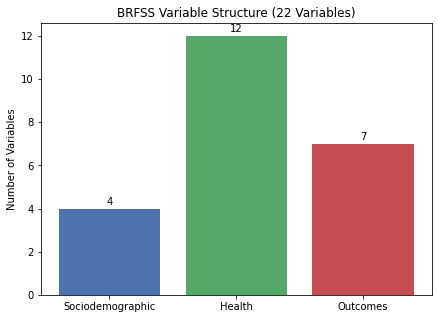

In [4]:
cdc_corr = data.corr()
print(cdc_corr.iloc[-1,:].sort_values(ascending=False))

groups = {
    "Sociodemographic": [
        "Sex", "Age", "Education", "Income"
    ],
    "Health": [
        "Smoker", "PhysActivity", "Fruits", "Veggies", "HealthyDiet",
        "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost",
        "CholCheck", "BMI", "HighBP", "HighChol"
    ],
    "Outcomes": [
        "Diabetes_binary", "GenHlth", "DiffWalk",
        "HeartDiseaseorAttack", "Stroke",
        "PhysHlth", "MentHlth"
    ]
}

counts = {k: len(v) for k, v in groups.items()}

plt.figure(figsize=(7,5))
bars = plt.bar(
    counts.keys(),
    counts.values(),
    color=["#4C72B0", "#55A868", "#C44E52"]
)

plt.title("BRFSS Variable Structure (22 Variables)")
plt.ylabel("Number of Variables")

# optional labels inside bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval),
             ha='center', va='bottom')

plt.show()

In [5]:
#split
def data_split(data):
    
    X = data.iloc[:,:-1]
    y = data.iloc[:,-1]
    
    train_x, temp_x, train_y, temp_y = train_test_split(X,y,test_size = 0.3, random_state=0)

    test_x, val_x, test_y, val_y = train_test_split(temp_x, temp_y, test_size=0.3333, random_state=0, stratify=temp_y)


# Check sizes
    print("Train size:", len(train_x))
    print("Test size:", len(test_x))
    print("Validation size:", len(val_x))
    
    return train_x, test_x, train_y, test_y, val_x, val_y

train_x, test_x, train_y, test_y, val_x, val_y = data_split(data)

Train size: 160631
Test size: 45897
Validation size: 22946


In [6]:

train_df = pd.concat([train_x, train_y], axis=1)
test_df  = pd.concat([test_x, test_y], axis=1)
val_df   = pd.concat([val_x, val_y], axis=1)

train_df.to_csv("cdc_train.csv", index=False)
test_df.to_csv("cdc_test.csv", index=False)
val_df.to_csv("cdc_validation.csv", index=False)


In [7]:
class FeatureSelectorDF(BaseEstimator, TransformerMixin):
    def __init__(self, score_func=f_classif, k=20):
        self.score_func = score_func
        self.k = k
    
    def fit(self, X, y=None):
        self.selector = SelectKBest(score_func=self.score_func, k=self.k)
        self.selector.fit(X, y)
        self.columns_ = X.columns[self.selector.get_support()]
        return self
    
    def transform(self, X):
        X_selected = self.selector.transform(X)
        return pd.DataFrame(X_selected, columns=self.columns_, index=X.index)

/storage/home/tvw5517/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [19:59:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/storage/home/tvw5517/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [19:59:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/storage/home/tvw5517/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [19:59:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/storage/home/tvw5517/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [19:59:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

[LightGBM] [Info] Number of positive: 19641, number of negative: 108863
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006567 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 199
[LightGBM] [Info] Number of data points in the train set: 128504, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.152843 -> initscore=-1.712471
[LightGBM] [Info] Start training from score -1.712471
[LightGBM] [Info] Number of positive: 19642, number of negative: 108863
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006582 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 199
[LightGBM] [Info] Number of data points in the train set: 128505, number of used features: 20
[LightGBM] [Info

/storage/home/tvw5517/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/storage/home/tvw5517/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/storage/home/tvw5517/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/storage/home/tvw55

                      Accuracy  Precision    Recall       AUC
Model                                                        
Extra Trees           0.835094   0.407899  0.174446  0.750462
Decision Tree         0.774141   0.288146  0.324739  0.589802
Random Forest         0.844339   0.473958  0.167318  0.776240
KNN                   0.831471   0.392914  0.188050  0.693971
AdaBoost              0.851504   0.545963  0.170454  0.805071
HistGradientBoosting  0.853372   0.575758  0.154570  0.813709
XGBoost               0.851728   0.548147  0.170862  0.808460
LightGBM              0.853851   0.580465  0.158113  0.813890
CatBoost              0.852276   0.555183  0.168459  0.811607
C5.0                  0.847147   0.000000  0.000000  0.499996


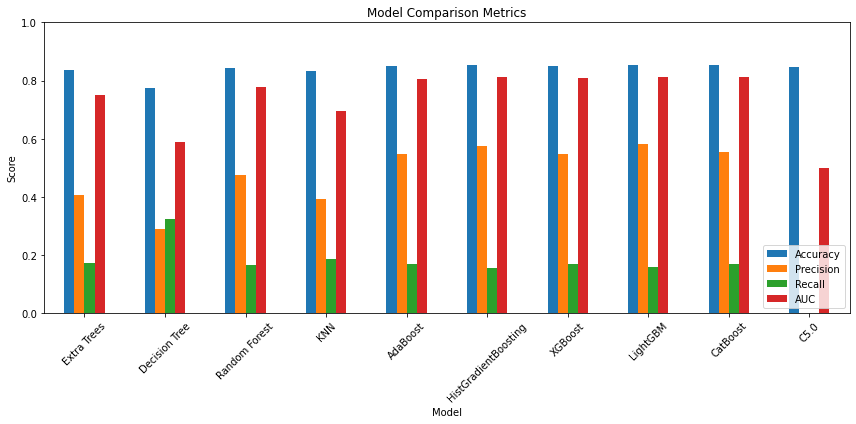

In [8]:
# parent code with c5
# Assuming FeatureSelectorDF is the feature selection class

models = {
    "Extra Trees": ExtraTreesClassifier(random_state=0),
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(random_state=0),
    "KNN": KNeighborsClassifier(),
    "AdaBoost": AdaBoostClassifier(random_state=0),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=0),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}

results = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

for name, model in models.items():
    acc_list, prec_list, rec_list, auc_list = [], [], [], []
    
    pipeline = Pipeline([
        ('feature_selection', FeatureSelectorDF(k=20)),
        ('model', model)
    ])
    
    for train_idx, val_idx in skf.split(train_x, train_y):
        X_train, X_val = train_x.iloc[train_idx], train_x.iloc[val_idx]
        y_train, y_val = train_y.iloc[train_idx], train_y.iloc[val_idx]
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_val)
        y_prob = pipeline.predict_proba(X_val)[:,1] if hasattr(pipeline, "predict_proba") else y_pred
        
        acc_list.append(accuracy_score(y_val, y_pred))
        prec_list.append(precision_score(y_val, y_pred))
        rec_list.append(recall_score(y_val, y_pred))
        auc_list.append(roc_auc_score(y_val, y_prob))
        
    results.append({
        'Model': name,
        'Accuracy': np.mean(acc_list),
        'Precision': np.mean(prec_list),
        'Recall': np.mean(rec_list),
        'AUC': np.mean(auc_list)
    })

#Run C5.0 separately
from c50py import C5Classifier

acc_list, prec_list, rec_list, auc_list = [], [], [], []

for train_idx, val_idx in skf.split(train_x, train_y):
    X_train, X_val = train_x.iloc[train_idx], train_x.iloc[val_idx]
    y_train, y_val = train_y.iloc[train_idx], train_y.iloc[val_idx]
    
    model = C5Classifier()
    model.feature_names = list(X_train.columns)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:,1]
    
    acc_list.append(accuracy_score(y_val, y_pred))
    prec_list.append(precision_score(y_val, y_pred))
    rec_list.append(recall_score(y_val, y_pred))
    auc_list.append(roc_auc_score(y_val, y_prob))

results.append({
    'Model': "C5.0",
    'Accuracy': np.mean(acc_list),
    'Precision': np.mean(prec_list),
    'Recall': np.mean(rec_list),
    'AUC': np.mean(auc_list)
})

#Convert to DataFrame
df_results = pd.DataFrame(results)
df_results = df_results.set_index('Model')
print(df_results)

#Plotting
df_results.plot(kind='bar', figsize=(12,6))
plt.title("Model Comparison Metrics")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Train size: 160631
Test size: 45897
Validation size: 22946
Exercise ATE: -0.03334183933624663
Diet ATE: -0.009952764908017806
count    45897.000000
mean        -0.033342
std          0.029585
min         -0.144907
25%         -0.053909
50%         -0.029838
75%         -0.008644
max          0.042486
dtype: float64
count    45897.000000
mean        -0.009953
std          0.020527
min         -0.095773
25%         -0.020952
50%         -0.008238
75%          0.001329
max          0.110121
dtype: float64


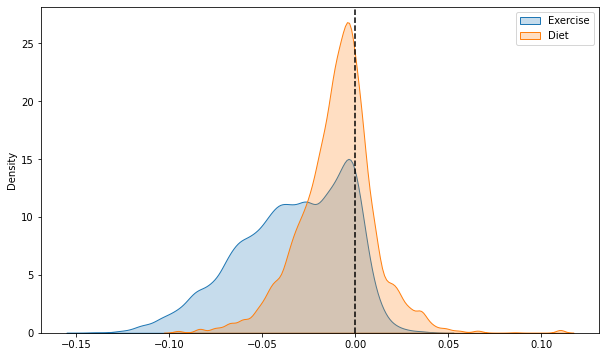

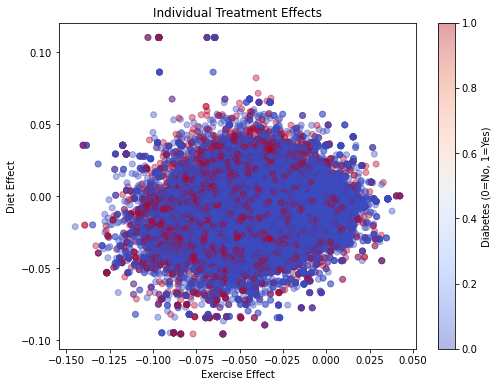

Exercise recommendation rate: 0.8829117371505762
Diet recommendation rate: 0.7188269385798636
Combined recommendation rate: 0.963134845414733
                Metric  Exercise    Diet
0                  ATE   -0.0333 -0.0100
1  Recommendation Rate    0.8829  0.7188
2           Min Effect   -0.1449 -0.0958
3         25% Quantile   -0.0539 -0.0210
4               Median   -0.0298 -0.0082
5         75% Quantile   -0.0086  0.0013
6           Max Effect    0.0425  0.1101

Combined Recommendation Rate: 0.9631


In [9]:
#Run this as the main novel approach code
# Feature engineering (before split)

data["HealthyDiet"] = (
    (data["Fruits"] > 0) & (data["Veggies"] > 0)
).astype(int)

data["Diabetes_binary"] = data.pop("Diabetes_binary")

train_x, test_x, train_y, test_y, val_x, val_y = data_split(data)


T_train_ex = train_x["PhysActivity"].values
T_test_ex  = test_x["PhysActivity"].values
T_val_ex   = val_x["PhysActivity"].values

T_train_diet = train_x["HealthyDiet"].values
T_test_diet  = test_x["HealthyDiet"].values
T_val_diet   = val_x["HealthyDiet"].values


leakage_cols = [
    "PhysActivity",
    "BMI",
    "GenHlth",
    "PhysHlth",
    "DiffWalk",
    "HeartDiseaseorAttack",
    "Stroke"
]

diet_leakage = [
    "HealthyDiet",
    "Fruits",
    "Veggies"
]


X_train_ex = train_x.drop(columns=leakage_cols, errors="ignore")
X_test_ex  = test_x.drop(columns=leakage_cols, errors="ignore")
X_val_ex   = val_x.drop(columns=leakage_cols, errors="ignore")

X_train_diet = train_x.drop(columns=leakage_cols + diet_leakage, errors="ignore")
X_test_diet  = test_x.drop(columns=leakage_cols + diet_leakage, errors="ignore")
X_val_diet   = val_x.drop(columns=leakage_cols + diet_leakage, errors="ignore")


Y_train = train_y.values
Y_test  = test_y.values
Y_val   = val_y.values


model_y = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=20,
    random_state=0,
    n_jobs=-1
)

model_t = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=20,
    random_state=0,
    n_jobs=-1
)


cf_ex = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    n_estimators=500,
    min_samples_leaf=50,
    max_depth=15,
    random_state=0,
    discrete_treatment=True
)

cf_ex.fit(Y_train, T_train_ex, X=X_train_ex)

effect_test_ex = cf_ex.effect(X_test_ex)
effect_val_ex  = cf_ex.effect(X_val_ex)


cf_diet = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    n_estimators=500,
    min_samples_leaf=50,
    max_depth=15,
    random_state=0,
    discrete_treatment=True
)

cf_diet.fit(Y_train, T_train_diet, X=X_train_diet)

effect_test_diet = cf_diet.effect(X_test_diet)
effect_val_diet  = cf_diet.effect(X_val_diet)


print("Exercise ATE:", effect_test_ex.mean())
print("Diet ATE:", effect_test_diet.mean())

print(pd.Series(effect_test_ex).describe())
print(pd.Series(effect_test_diet).describe())


plt.figure(figsize=(10,6))
sns.kdeplot(effect_test_ex, label="Exercise", fill=True)
sns.kdeplot(effect_test_diet, label="Diet", fill=True)
plt.axvline(0, linestyle='--', color='black')
plt.legend()
plt.show()


plt.figure(figsize=(8,6))

plt.scatter(
    effect_test_ex,
    effect_test_diet,
    c = Y_test,
    cmap = "coolwarm",
    alpha=0.4
)

plt.colorbar(label="Diabetes (0=No, 1=Yes)")
plt.xlabel("Exercise Effect")
plt.ylabel("Diet Effect")
plt.title("Individual Treatment Effects")

plt.show()


recommend_ex = (effect_test_ex < 0)
recommend_diet = (effect_test_diet < 0)
combined_policy = recommend_ex | recommend_diet

print("Exercise recommendation rate:", recommend_ex.mean())
print("Diet recommendation rate:", recommend_diet.mean())
print("Combined recommendation rate:", combined_policy.mean())

#Table for stats
summary_table = pd.DataFrame({
    "Metric": [
        "ATE",
        "Recommendation Rate",
        "Min Effect",
        "25% Quantile",
        "Median",
        "75% Quantile",
        "Max Effect"
    ],
    "Exercise": [
        effect_test_ex.mean(),
        (effect_test_ex < 0).mean(),
        effect_test_ex.min(),
        np.percentile(effect_test_ex, 25),
        np.median(effect_test_ex),
        np.percentile(effect_test_ex, 75),
        effect_test_ex.max()
    ],
    "Diet": [
        effect_test_diet.mean(),
        (effect_test_diet < 0).mean(),
        effect_test_diet.min(),
        np.percentile(effect_test_diet, 25),
        np.median(effect_test_diet),
        np.percentile(effect_test_diet, 75),
        effect_test_diet.max()
    ]
})

# Add combined policy separately
combined_rate = ( (effect_test_ex < 0) | (effect_test_diet < 0) ).mean()

print(summary_table.round(4))
print("\nCombined Recommendation Rate:", round(combined_rate, 4))

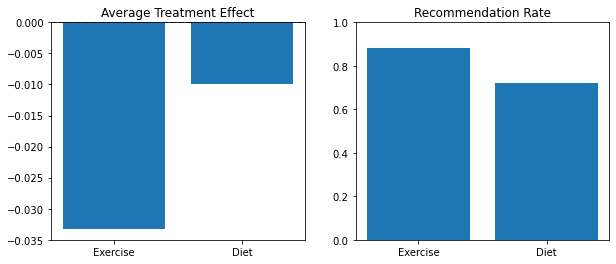

In [10]:
#Bar Graph
fig, ax = plt.subplots(1, 2, figsize=(10,4))

# ATE plot
ax[0].bar(["Exercise", "Diet"], [
    effect_test_ex.mean(),
    effect_test_diet.mean()
])
ax[0].set_title("Average Treatment Effect")
ax[0].axhline(0, linestyle="--", color="black")

# Recommendation rate plot
ax[1].bar(["Exercise", "Diet"], [
    recommend_ex.mean(),
    recommend_diet.mean()
])
ax[1].set_title("Recommendation Rate")
ax[1].set_ylim(0,1)

plt.show()